In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy.linalg import solve, block_diag
from numpy import block
import pandas as pd

## Problem 1: linear data fitting

In this problem, you are trying to find an approximation to the periodic function $f(t)=e^{\sin(t-1)}$ over one period, $0\leq t\leq 2\pi$.

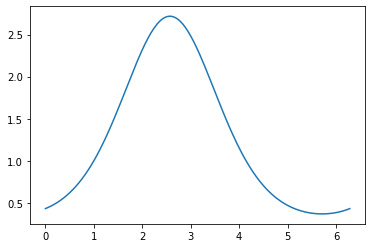

In [3]:
m = 200
t = np.linspace(0,2*np.pi,m)
y = np.exp(np.sin(t-1))
plt.plot(t,y)

**Part 1 (polynomial approximation):** Find the coefficients of the least squares fit

$$
f(t) \approx c_1 + c_2t + \cdots + c_7 t^7
$$

In [4]:
# fit a degree-d polynomial
d =6
A = np.ones((m,d+1))
for i in range(d+1):
     A[:,i] = t**i

# solve least squares problem
coeffs_a = lstsq(A,y)[0]
coeffs_a

array([ 0.58813557, -0.85735887,  1.60715159, -0.19406438, -0.16840821,
        0.04600638, -0.00322374])

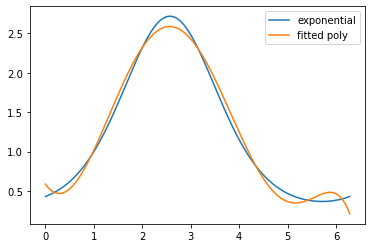

In [5]:
#plot the result
plt.plot(t,y,label = 'exponential')
y_pred = A.dot(coeffs_a.T)
plt.plot(t,y_pred,label='fitted poly')
plt.legend()

**Part 2 (trigonometric polynomial approximation):** Find the coefficients of the least squares fit

$$
f(t) \approx d_1 + d_2\cos(t) + d_3 \sin(t) + d_4\cos(2t) + d_5\sin(2t).
$$

In [6]:
# fit a trig poly
d =4
B = np.ones((m,d+1))
B[:,1]=np.cos(t)
B[:,2]=np.sin(t)
B[:,3]=np.cos(2*t)
B[:,4]=np.sin(2*t)

# solve least squares problem
coeffs_b = lstsq(B,y)[0]
coeffs_b

array([ 1.26608136, -0.95109901,  0.61071353,  0.11301289, -0.24687001])

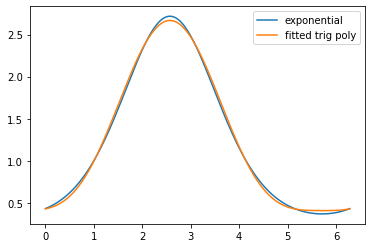

In [7]:
#plot the result
plt.plot(t,y,label = 'exponential')
y_pred2 = B.dot(coeffs_b.T)
plt.plot(t,y_pred2,label='fitted trig poly')
plt.legend()

**Part 3:** Plot the original function $f(t)$ and the two approximations from parts 1 and 2 together (on a well-labeled graph).

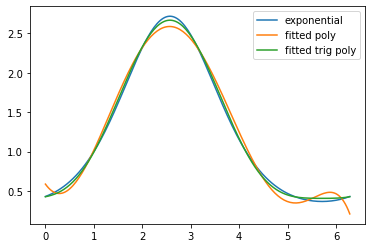

In [8]:
#plot the result
plt.plot(t,y,label = 'exponential')
plt.plot(t,y_pred,label='fitted poly')
plt.plot(t,y_pred2,label='fitted trig poly')
plt.legend()

## Problem 2: constrained data fitting

Consider the following data points

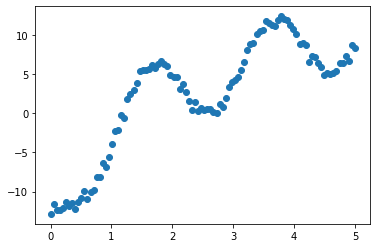

In [9]:
m = 100
t = np.linspace(0,5,m)
y = 5+.1*t-4*np.sin(np.pi*t)+2*np.cos(np.pi*t)-20*np.exp(-t)+0.1*t**(2.5)+0.5*np.random.randn(m)
plt.scatter(t,y)

Find the coefficients of the least squares fit

$$
f(t) = a_1 + a_2t+a_3\sin(\pi t)+ a_4\cos(\pi t)+a_5e^{-t} + a_6t^{2.5}
$$

such that $f(5)=11$ and $f^\prime(0)=0$.
Then plot the data points and the fitted function.

In [10]:
# define matrix A

dim = 6
A = np.ones((m,dim))
A[:,1] = t
A[:,2] = np.sin(np.pi*t)
A[:,3] = np.cos(np.pi*t)
A[:,4] = np.exp(-t)
A[:,5] = t**(2.5)

We now define the constraint matrix- observe that the function $f(t)$ has derivative 

$$
f'(t) = 0 + a_2 + \pi a_2\cos(\pi t) - \pi a_4 \sin(\pi t) - a_5 e^{-t} +2.5 a_6 t^{1.5}
$$

which implies that $f'(0) = 0+a_2+\pi a_3 - 0 -a_5 +0 = 0$

In [12]:
C = np.array([[1,5,np.sin(np.pi*5),np.cos(np.pi*5),np.exp(-5),5**2.5],
              [0,1,np.pi,0,-1,0]])
d= np.array([11,0])

In [13]:
b=y
Matrix = np.block([[2*A.T.dot(A),C.T],[C,np.zeros((2,2))]])
vector = np.concatenate((2*A.T.dot(b),d))
solution = solve(Matrix, vector)

In [14]:
coeffs = solution[:6]
C.dot(coeffs.T)

array([ 1.10000000e+01, -1.77635684e-15])

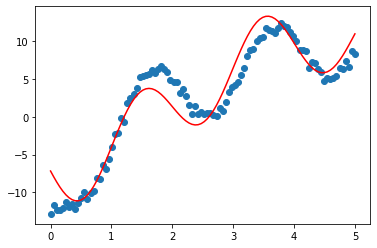

In [15]:
# plot fitted polynomial
plt.scatter(t,y)
plt.plot(t,A.dot(coeffs.T),color='red')
# ?????

## Problem 3: fitting an exponential to data

**Introduction**: The most familiar and common case of a polynomial least squares fit is the straight line $y=f(t)=at+b$.
Certain other fit functions can be transformed into this situation.
For example, suppose you want to fit data using $y = c_1e^{c_2t}$.
Then, 

$$
\log(y) = \log(c_1) + c_2t
$$

Thus, the variable $\log(y)$ can be fitted linearly in terms of the variable $t$.

Similarly, the power-law $y=c_1 t^{c_2}$ is equivalent to

$$
\log(y) = \log(c_1) + c_2 \log(t)
$$

Thus, the variable  $\log(𝑦)$  can be fitted linearly in terms of the variable  $\log(t)$.

In python, these two cases (exponential fit and power law) are easily discerned by using `plt.semilogy` or `plt.loglog` plots respectively

**Part 0:** Consider the following data points

Text(0.5, 1.0, 'plot with log scaling on both the x and y axis')

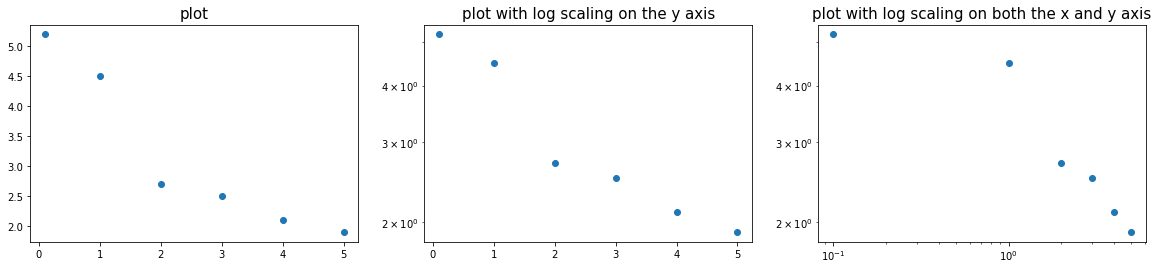

In [70]:
X = np.array([
    [0.1,1,2,3,4,5],
    [5.2,4.5,2.7,2.5,2.1,1.9]
])

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.title('plot with log scaling on the y axis', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.title('plot with log scaling on both the x and y axis', fontsize=15)

**Part 1:** Fit a line to the data points. 

In [75]:
A = np.ones((6,2))
A[:,1] = X[0]

line_coeffs = lstsq(A,X[1])[0]

**Part 2:** Fit an exponential function $f(t)=c_1e^{c_2t}$ to the data points.

In [76]:
A = np.ones((6,2))
A[:,1] = X[0]

exp_coeffs = lstsq(A,np.log(X[1]))[0]

**Part 3:** Fit a power-law function $f(t)=c_1 t^{c_2}$ to the data points. 

In [74]:
A2 = np.ones((6,2))
A2[:,1] = np.log(X[0])

plaw_coeffs = lstsq(A2,np.log(X[1]))[0]

**Part 4:** Plot the data points, and the three fitted functions from parts 1, 2 and 3 (on a well-labeled graph)

Text(0.5, 1.0, 'plot with log scaling on both the x and y axis')

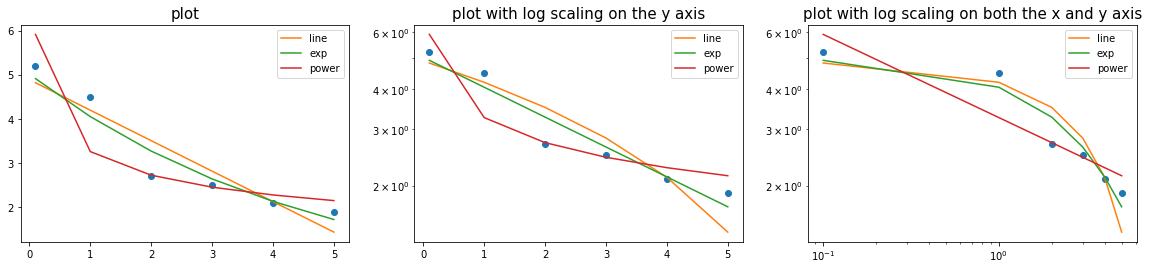

In [81]:
plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.plot(X[0],A.dot(line_coeffs.T),label='line')
plt.plot(X[0],np.exp(A.dot(exp_coeffs.T)),label='exp')
plt.plot(X[0],np.exp(A2.dot(plaw_coeffs.T)),label='power')
plt.legend()
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.plot(X[0],A.dot(line_coeffs.T),label='line')
plt.plot(X[0],np.exp(A.dot(exp_coeffs.T)),label='exp')
plt.plot(X[0],np.exp(A2.dot(plaw_coeffs.T)),label='power')
plt.legend()
plt.title('plot with log scaling on the y axis', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.plot(X[0],A.dot(line_coeffs.T),label='line')
plt.plot(X[0],np.exp(A.dot(exp_coeffs.T)),label='exp')
plt.plot(X[0],np.exp(A2.dot(plaw_coeffs.T)),label='power')
plt.legend()
plt.title('plot with log scaling on both the x and y axis', fontsize=15)

## Problem 4: numerical approximations to $\pi$

A famous series for finding $\pi$ is

$$
\frac{\pi^2}{6} = 1 + \frac{1}{2^2} + \frac{1}{3^2} + \frac{1}{4^2} + \frac{1}{5^2} + \cdots
$$

Let us denote by $s_k$ the sum of the first $k$ terms of the series above, and let $p_k=\sqrt{6s_k}$.
Here is a fancy way to compute these sequences in a compact code (using list comprehensions and `numpy`'s `cumsum` function).

In [99]:
k_max = 100
s = np.cumsum([1/i**2 for i in range(1,k_max)]) # cumulative summation
p = np.sqrt(6*s)

Text(0.5, 1.0, 'sequence converging to $\\pi$')

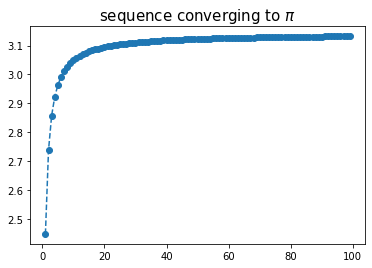

In [100]:
plt.plot(range(1,k_max), p,'o--')
plt.title('sequence converging to $\pi$',fontsize=15)

The graph suggests that $p_k\rightarrow \pi$ but doesn't give much information about the rate of convergence.

Let $e_k=|\pi-p_k|$ be the sequence of errors

Text(0.5, 1.0, 'loglog plot')

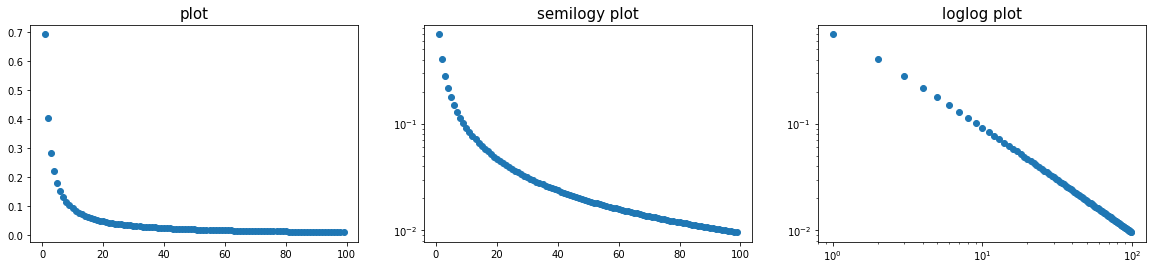

In [101]:
# sequence of errors
e = np.abs(np.pi - p)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(range(1,k_max),e,'o')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(range(1,k_max),e,'o')
plt.title('semilogy plot', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(range(1,k_max),e,'o')
plt.title('loglog plot', fontsize=15)

The loglog plot suggests a power-law relationship $e_k = c_1k^{c_2}$

**Part 1:** Find the parameters $c_1$ and $c_2$.

In [102]:
x_log = np.log(range(1,k_max))
y_log = np.log(np.abs(np.pi - p))

A = np.ones((len(x_log),2))
A[:,1] = x_log
log_of_coeffs = lstsq(A,y_log)[0]

[c_1,c_2] = np.exp(log_of_coeffs)
[c_1,c_2]

[0.8328279686649989, 0.38014226287940395]

**Part 2:** Another series for finding $\pi$ is

$$
\frac{\pi}{2} = 1 + \frac{1}{3} + \frac{1 \cdot 2}{3 \cdot 5} + \frac{1 \cdot 2 \cdot 3}{3 \cdot 5 \cdot 7} + \frac{1 \cdot 2 \cdot 3 \cdot 4}{3 \cdot 5 \cdot 7 \cdot 9} + \cdots
$$

Define $s_k$ to be the sum of the first $k$ terms, and let $e_k=|\pi-2s_k|$.
Do a numerical experiment to determine which is a better fit, $e_k=c_1 c_2^k$ or $e_k=c_1 k^{c_2}$.
Then determine the parameters $c_1,c_2$ in that fit.

In [103]:
k_max = 50
s = np.cumsum([2**(i-1)*np.math.factorial(i-1)**2/np.math.factorial(2*i-1) for i in range(1,k_max)]) # cumulative summation
p = 2*s

Text(0.5, 1.0, 'loglog plot')

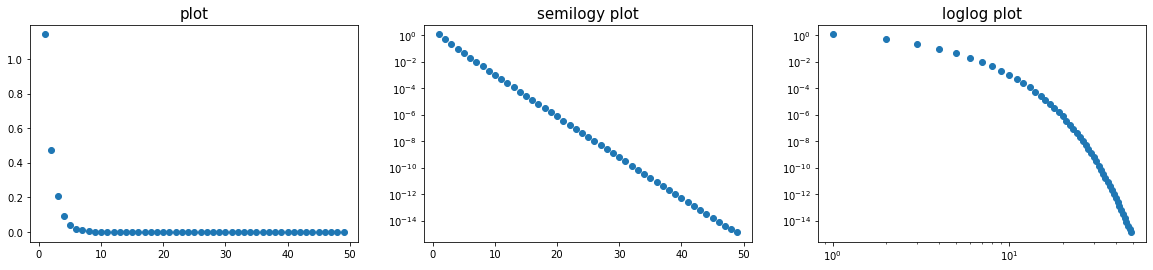

In [104]:
# sequence of errors
e = np.abs(np.pi - p)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(range(1,k_max),e,'o')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(range(1,k_max),e,'o')
plt.title('semilogy plot', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(range(1,k_max),e,'o')
plt.title('loglog plot', fontsize=15)

The second plot makes me think a fit of the form $e_k=c_1c_2^{k}$ will be better.

In [105]:
x = range(1,k_max)
y_log = e = np.log(np.abs(np.pi - p))

A = np.ones((len(x),2))
A[:,1] = x
solution = lstsq(A,y_log)[0]


[c_1,c_2] = [solution[0],np.exp(solution[1])]

[c_1,c_2]

[0.3147474767422837, 0.4887676083235831]

## Problem 5: nonlinear data fitting

**Part 1:** Inhibited enzyme reactions often follow what are known as *Michaelis-Menten* kinetics, in which a reaction rate follows a law of the form

$$
v(t) = \frac{Vt}{K+t},
$$
where $t$ is the concentration of a substrate.

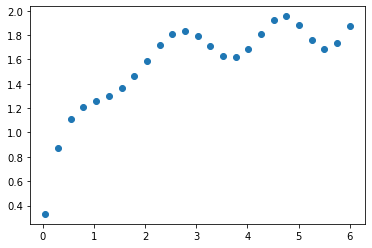

In [25]:
# generate some synthetic data with V=2 and K=1/2
m = 25
t = np.linspace(0.05,6,m)
y = 2*t/(0.5+t) + 0.15*np.cos(2*np.exp(t/16)*t)
plt.scatter(t,y)

Use nonlinear least squares to fit a function of the form $v(t) = \frac{Vt}{K+t}$ to the data. 
Then plot the data and the fitted function.

In [26]:
# we expect x to have two entries- x[0] is our guess for V and x[1] is our guess for K
def fun(x,t,y):
    return x[0]*t/(x[1]+t) - y

In [28]:
# jacobian of above function for changing V and K
def Dfun(x,t,y):
    m= len(t)
    col_1=t/(x[1]+t)
    col_2=-x[0]*t/(x[1]+t)**2
    return np.hstack((col_1.reshape(m,1),col_2.reshape(m,1)))

In [33]:
# Gauss-Newton
x = np.array([2,1])
it = 10
error = []
for i in range(it):
    f = fun(x,t,y)
    Der = Dfun(x,t,y)
    x = x - np.linalg.inv((Der.T.dot(Der))).dot(Der.T.dot(f))
    error.append(np.linalg.norm(f))

x

array([1.9686526 , 0.46930373])

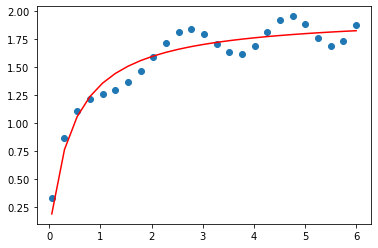

In [35]:
# let's try plotting?
y_pred = x[0]*t/(x[1]+t)

plt.scatter(t,y)
plt.plot(t,y_pred, color = 'red')

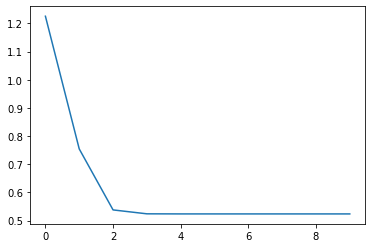

In [36]:
# let's plot the error for fun

plt.plot(error)

**Part 2:** A famous result suggests that in epidemics that kill only a small fraction of a susceptible population, the **death rate** as a function of time is well modeled by

$$
A\,\mathrm{sech}^2\,\left(B(t-C)\right),
$$

where $\mathrm{sech}$ is the hyperbolic secant.

You will use this model to fit the deaths per week from plague recorded in Mumbai in a period during 1906.

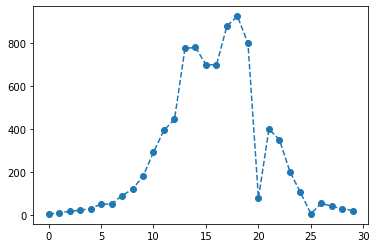

In [40]:
deaths = np.array([
    5,10,17,22,30,50,51,90,120,180,292,395,445,775,780,700,698,880,925,800,78,400,350,202,105,6,55,40,30,20
])
plt.plot(deaths,'o--')

Find the best least squares fit to the data. 
Make a plot of the fitted model and the data points.

In [60]:
y = deaths
t = np.array(range(len(y)))

In [54]:
# we expect x to have three entries- x = [A,B,C]
def fun(x,t,y):
    return x[0]/(np.cosh(x[1]*(t-x[2])))**2 - y

In [63]:
# Jacobian of f(x)
def Dfun(x,t,y):
    m = len(t)
    col1 = 1/(np.cosh(x[1]*(t-x[2])))**2
    col2 = -2*x[0]*(t-x[2])*np.tanh(x[1]*(t-x[2]))*(1/np.cosh(x[1]*(t-x[2])))**2
    col3 = 2*x[0]*x[1]*np.tanh(x[1]*(t-x[2]))*(1/np.cosh(x[1]*(t-x[2])))**2
    return np.hstack((col1.reshape(m,1),col2.reshape(m,1),col3.reshape(m,1)))

In [73]:
# Gauss-Newton: guess an x by looking at data 
x = np.array([900,0.3,16])
it = 10
error = []
for i in range(it):
    f = fun(x,t,y)
    Der = Dfun(x,t,y)
    x = x - np.linalg.inv((Der.T.dot(Der))).dot(Der.T.dot(f))
    error.append(np.linalg.norm(f))
    
x

array([8.60132977e+02, 1.98172182e-01, 1.59194128e+01])

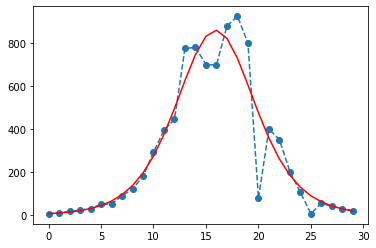

In [75]:
deaths = np.array([
    5,10,17,22,30,50,51,90,120,180,292,395,445,775,780,700,698,880,925,800,78,400,350,202,105,6,55,40,30,20
])
plt.plot(deaths,'o--')
#plt.plot(t,900/(np.cosh(0.3*(t-16)))**2)
plt.plot(t,x[0]/(np.cosh(x[1]*(t-x[2])))**2,color = 'red')


In [76]:
#note: This shows the instability of the algorithm; you have to guess a fairly accurate initial x to
#get meaningful results

## Problem 6: (linear) fitting of an ellipse

An ellipse in a plane can be described (implicitly) as the set of points $\begin{bmatrix} 
x \\ y 
\end{bmatrix}$ that satisfy

$$
f(x,y) = ax^2 + bxy + cy^2 + dx + ey = 1,
$$

where $a,b,c,d,e$ are the parameters that describe the ellipse.

Your goal is to fit an ellipse ro $m$ points $\begin{bmatrix} x_1 \\ y_1 \end{bmatrix}, \begin{bmatrix} x_2 \\ y_2 \end{bmatrix}, \ldots, \begin{bmatrix} x_m \\ y_m \end{bmatrix}$ by minimizing 

$$
\sum_{i=1}^m (f(x_i,y_i)-1)^2
$$

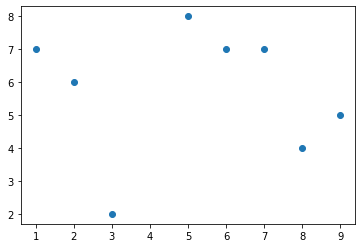

In [77]:
# m=8 points in R2
X = np.array([
    [1, 2, 5, 7, 9, 6, 3, 8],
    [7, 6, 8, 7, 5, 7, 2, 4]
    ])
plt.scatter(X[0],X[1])

**Part 1:** Find the ellipse (i.e., find the parameters $a,b,c,d,e$) that best fits the $m=8$ given points.

In [85]:
A = np.zeros((8,5))
A[:,0] = X[0]*X[0]
A[:,1] = X[0]*X[1]
A[:,2] = X[1]*X[1]
A[:,3] = X[0]
A[:,4] = X[1]

b = np.ones(8)

coeffs = lstsq(A,b)[0]
coeffs

array([-0.01657585, -0.01772061, -0.0159288 ,  0.25648429,  0.23247096])

**Part 2:** Plot the given points and the fitted ellipse.

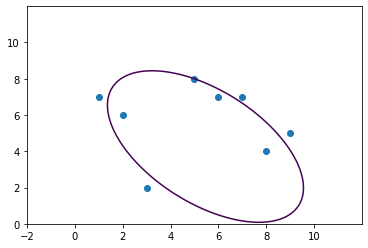

In [93]:
plt.scatter(X[0],X[1])
# set x and y ranges and precision
x = np.arange(-2,12,0.01) 
y = np.arange(0,12,0.01)
# create a grid
xx,yy=np.meshgrid(x,y)
# evaluate equation at grid points
zz = coeffs[0]*xx**2 + coeffs[1]*xx*yy + coeffs[2]*yy**2 + coeffs[3]*xx + coeffs[4]*yy 
# contour plot
plt.contour(xx,yy,zz,levels=[1])


Hint: to plot the ellipse, you'll need to use `plt.contour` function.
For example, the cell below plots the implicit curve $x^2+2y^2=4$

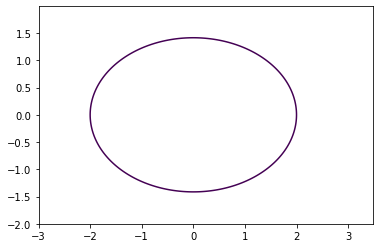

In [62]:
# set x and y ranges and precision
x = np.arange(-3,3.5,0.01) 
y = np.arange(-2,2,0.01)
# create a grid
xx,yy=np.meshgrid(x,y)
# evaluate equation at grid points
zz = xx**2 + 2*yy**2
# contour plot
plt.contour(xx,yy,zz,levels=[4])

## Problem 7: (non linear) fitting of an ellipse

An ellipse in a plane can be described (explicitly) as the set
of points 

$$
\begin{bmatrix} 
x \\ y 
\end{bmatrix}  = f(t) =
\begin{bmatrix} 
c_1 + r \cos(\alpha + t) + \delta \cos(\alpha-t) \\
c_2 + r \sin(\alpha + t) + \delta \sin(\alpha-t) 
\end{bmatrix},
$$

where t ranges from 0 to $2\pi$.
The vector $\theta = (c_1, c_2, r, \delta, \alpha)$ contains five parameters, with geometrical meanings illustrated in the figure below.

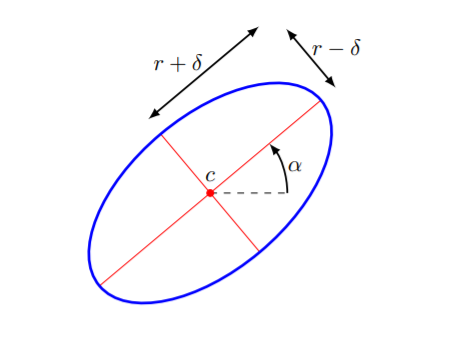

In [6]:
from IPython.display import Image
Image(filename="ellipse.png")

Your goal is to fit an ellipse by minimizing the sum of the squared distances of $m$ points $\begin{bmatrix} x_1 \\ y_1 \end{bmatrix}, \begin{bmatrix} x_2 \\ y_2 \end{bmatrix}, \ldots, \begin{bmatrix} x_m \\ y_m \end{bmatrix}$ to the
ellipse.


**Part 1:** Minimize the sum of the squared distances of the data points to the ellipse 

$$
\sum_{i=1}^m \left\| \begin{bmatrix}x_i\\y_i\end{bmatrix} - f(t_i) \right\|_2^2
$$

over $t_1,t_2,\ldots,t_m$ and $c_1, c_2, r, \delta, \alpha$

**Part 2:** Plot the given points and the fitted ellipse.

*NOTE*: These are attached on another notebook (the next page).

When I ran my code in this notebook, the error did not drop below 1e129 (big number!)  while in the other notebook, with the exact same code, it was single-digits. I could not figure out why and did not want to tempt fate.